In [1]:
import pandas as pd
import os

In [2]:
# Define the directory containing CSV files for new alpha values
csv_dir = '/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/new_alpha_values/test/scVI-classification-evals-4-7-26/'

# Define expected columns
columns = ['accuracy', 'precision', 'recall', 'micro_f1', 'macro_f1', 'seed', 'dataset', 'ARtype', 'latent_dim', 'Atlas_cell_count', 'alpha']

# Initialize an empty list to store DataFrames
df_list = []

# Loop over all CSV files in the directory
for file in os.listdir(csv_dir):
    if file.endswith(".csv"):
        file_path = os.path.join(csv_dir, file)
        df_temp = pd.read_csv(file_path, usecols=columns)  # Load only relevant columns
        df_list.append(df_temp)  # Store DataFrame in the list

# # Concatenate all DataFrames into one
# df = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame(columns=columns)


In [3]:
# Define the directory containing CSV files
csv_dir = '../result/test/sctab/zeinab-classification-evals-20250409-manuscript-version/'
alpha = 0.0001
# Loop over all CSV files in the directory
for file in os.listdir(csv_dir):
    if file.endswith(".csv"):
        file_path = os.path.join(csv_dir, file)
        df_temp = pd.read_csv(file_path)  # Load only relevant columns
        df_temp['alpha'] = alpha
        # print(df_temp.columns)
        # df_temp.columns = columns
        df_list.append(df_temp)  # Store DataFrame in the list

In [4]:
# Concatenate all DataFrames into one
df = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame(columns=columns)

In [5]:
# remove repeted rows
df = df.drop_duplicates()
# remove column Unnamed: 0
df = df.drop(columns=['Unnamed: 0'])
df.head()

,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,alpha
0,0.665092,0.640463,0.501320,0.665092,0.536389,46,Kidney,T,64,0,0.00001
1,0.678555,0.617196,0.538330,0.678555,0.555526,42,Kidney,T,64,1000,0.00100
2,0.882200,0.881993,0.818173,0.882200,0.831002,43,Neurons,T,64,50000,0.00001
3,0.690128,0.636998,0.532836,0.690128,0.557856,43,Kidney,T,64,100,0.00001
4,0.877893,0.837209,0.785262,0.877893,0.805807,45,Kidney,T,64,50000,0.00100


In [6]:
# assert df[df['ARtype'] == 'AR'].shape[0] == df[df['ARtype'] == 'Naive'].shape[0]
# assert if the number of rows for each seed is the same
assert df[df['seed'] == '42'].shape[0] \
    == df[df['seed'] == '43'].shape[0] \
    == df[df['seed'] == '44'].shape[0] \
    == df[df['seed'] == '45'].shape[0] \
    == df[df['seed'] == '46'].shape[0] 

print("df[df['seed'] == '42'].shape[0]:", df[df['seed'] == 42].shape[0])
print("df[df['seed'] == '43'].shape[0]:", df[df['seed'] == 43].shape[0])
print("df[df['seed'] == '44'].shape[0]:", df[df['seed'] == 44].shape[0])
print("df[df['seed'] == '45'].shape[0]:", df[df['seed'] == 45].shape[0])
print("df[df['seed'] == '46'].shape[0]:", df[df['seed'] == 46].shape[0])

# print number of rows for each dataset
print('number of rows for each dataset:', df['dataset'].value_counts())

# print number of rows for each dataset, alpha
print('number of rows for each dataset, alpha:', df.groupby(['dataset', 'alpha']).size())

# print number of rows for each dataset, alpha, seed
print('number of rows for each dataset, alpha, seed:', df.groupby(['dataset', 'alpha', 'seed']).size())


# print number of rows for each dataset, alpha, atlas_cell_count
print('number of rows for each dataset, alpha, atlas_cell_count:', df.groupby(['dataset', 'alpha', 'Atlas_cell_count']).size())




df[df['seed'] == '42'].shape[0]: 84
df[df['seed'] == '43'].shape[0]: 84
df[df['seed'] == '44'].shape[0]: 84
df[df['seed'] == '45'].shape[0]: 84
df[df['seed'] == '46'].shape[0]: 84
number of rows for each dataset: dataset
Kidney     140
Neurons    140
Heart      140
Name: count, dtype: int64
number of rows for each dataset, alpha: dataset  alpha  
Heart    0.00001    35
         0.00010    70
         0.00100    35
Kidney   0.00001    35
         0.00010    70
         0.00100    35
Neurons  0.00001    35
         0.00010    70
         0.00100    35
dtype: int64
number of rows for each dataset, alpha, seed: dataset  alpha    seed
Heart    0.00001  42       7
                  43       7
                  44       7
                  45       7
                  46       7
         0.00010  42      14
                  43      14
                  44      14
                  45      14
                  46      14
         0.00100  42       7
                  43       7
              

In [7]:
df.columns = ['Accuracy', 'Precision', 'Recall', 'Micro F1 Score', 'Macro F1 Score', 'deed', 'dataset', 'ARtype', 'latent_dim', 'Atlas_cell_count', 'Alpha']

In [8]:
import pandas as pd

# Define metrics and target columns
metrics = ['Accuracy', 'Precision', 'Recall', 'Micro F1 Score', 'Macro F1 Score']
columns = ['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'Alpha']
plot_df_list = []

# Loop through each row in df
for index, row in df.iterrows():
    for metric in metrics:
        tmp_df = pd.DataFrame([[row['dataset'], metric, row[metric], row['ARtype'], row['Atlas_cell_count'], row['Alpha']]], 
                              columns=columns)
        plot_df_list.append(tmp_df)

# Concatenate all DataFrames
plot_df = pd.concat(plot_df_list, ignore_index=True) if plot_df_list else pd.DataFrame(columns=columns)


In [9]:
plot_df = plot_df.sort_values(by=['Alpha', 'Atlas_cell_count', 'dataset', 'metric'])

# display all rows of plot_df
plot_df.head()

,dataset,metric,value,ARtype,Atlas_cell_count,Alpha
115,Heart,Accuracy,0.726348,T,0,0.00001
150,Heart,Accuracy,0.742706,T,0,0.00001
455,Heart,Accuracy,0.730032,T,0,0.00001
810,Heart,Accuracy,0.737106,T,0,0.00001
885,Heart,Accuracy,0.715591,T,0,0.00001


In [10]:
plot_df.tail()

,dataset,metric,value,ARtype,Atlas_cell_count,Alpha
567,Neurons,Recall,0.855417,T,50000,0.001
722,Neurons,Recall,0.784537,T,50000,0.001
767,Neurons,Recall,0.853513,T,50000,0.001
927,Neurons,Recall,0.800115,T,50000,0.001
1037,Neurons,Recall,0.843651,T,50000,0.001


In [11]:
# print number of rows of plot_df for each dataset, alpha, Atlas_cell_count only for Recall
print('number of rows of plot_df for each dataset, alpha, Atlas_cell_count only for Recall:', plot_df[plot_df['metric'] == 'Recall'].groupby(['dataset', 'Alpha', 'Atlas_cell_count']).size())


number of rows of plot_df for each dataset, alpha, Atlas_cell_count only for Recall: dataset  Alpha    Atlas_cell_count
Heart    0.00001  0                   5
                  1                   5
                  10                  5
                  100                 5
                  1000                5
                                     ..
Neurons  0.00100  10                  5
                  100                 5
                  1000                5
                  10000               5
                  50000               5
Length: 63, dtype: int64


In [12]:
# change ARtype to AR and Naive
plot_df['ARtype'] = plot_df['ARtype'].replace({'T': 'AR', 'F': 'Standard'})

In [13]:
# # write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and Naive using t-test
# from scipy import stats
# results = []
# for dataset in plot_df['dataset'].unique():
#     for metric in plot_df['metric'].unique():
#         for atlas_cell_count in plot_df['Atlas_cell_count'].unique():
#             ar_values = plot_df[(plot_df['dataset'] == dataset) & 
#                                 (plot_df['metric'] == metric) & 
#                                 (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
#                                 (plot_df['ARtype'] == 'AR') &
#                                 (plot_df['Alpha'] == 0.0001)]['value']
#             naive_values = plot_df[(plot_df['dataset'] == dataset) & 
#                                    (plot_df['metric'] == metric) & 
#                                    (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
#                                    (plot_df['ARtype'] == 'Standard') &
#                                    (plot_df['Alpha'] == 0.0001)]['value']
#             if len(ar_values) > 1 and len(naive_values) > 1:
#                 t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
#                 results.append([dataset, metric, atlas_cell_count, p_value])
#             else:
#                 results.append([dataset, metric, atlas_cell_count, None])

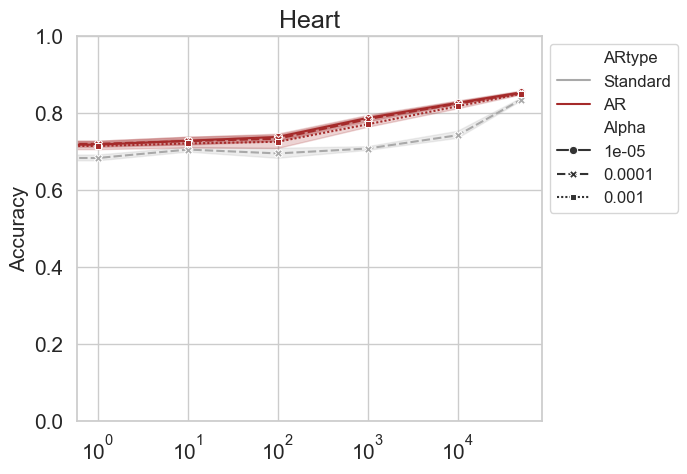

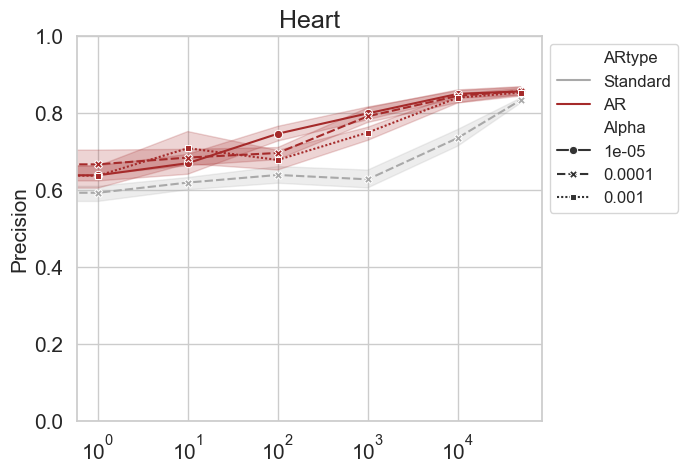

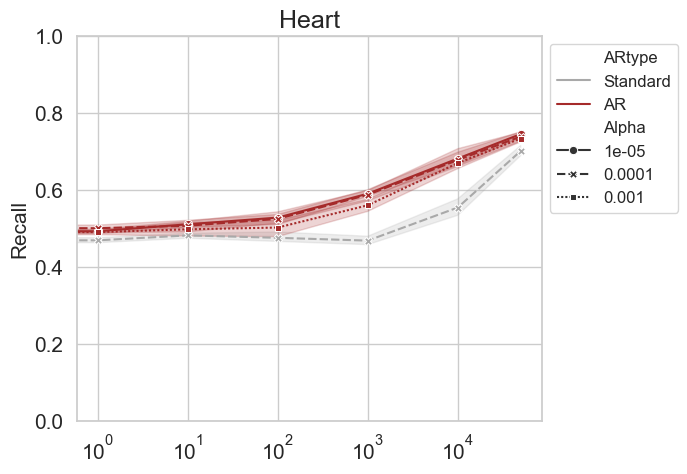

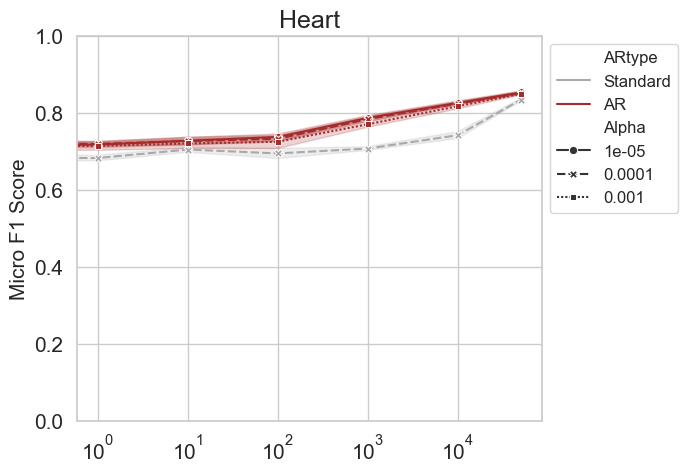

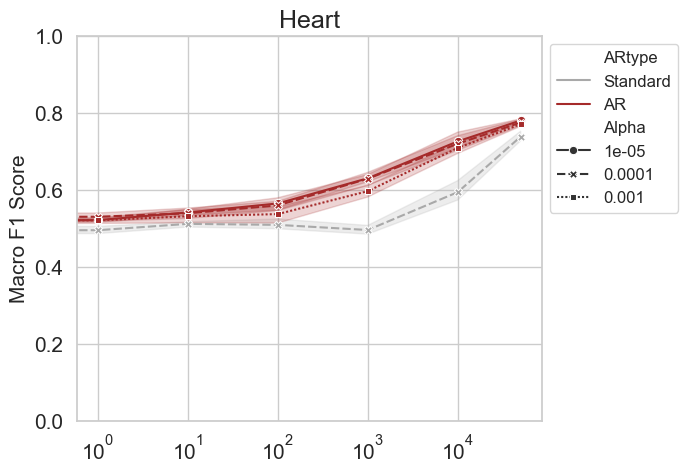

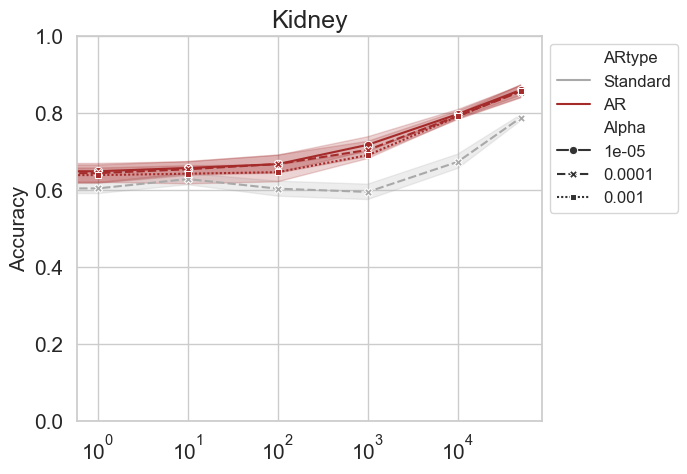

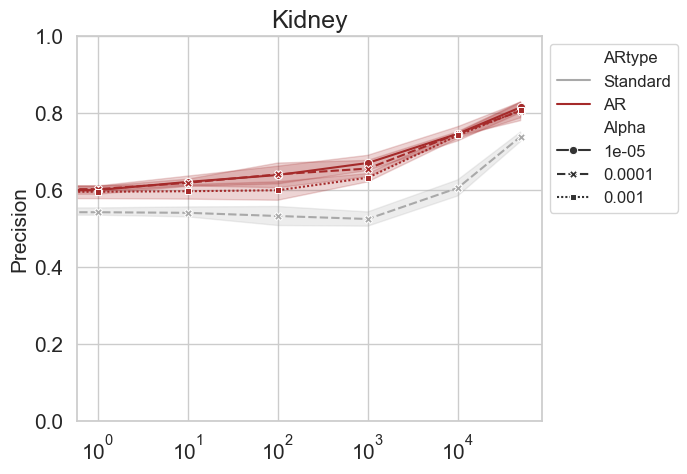

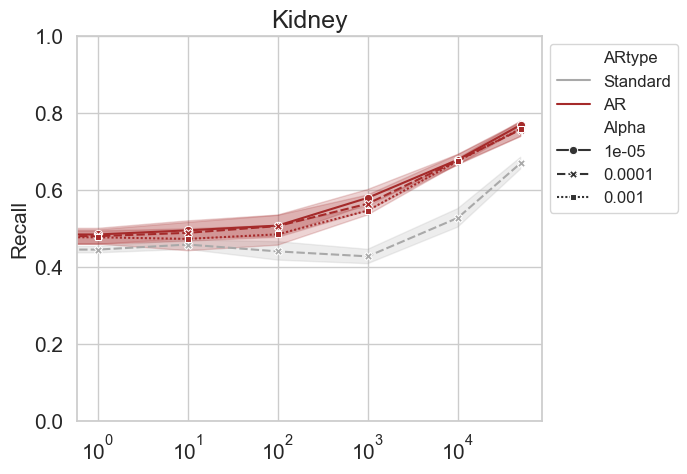

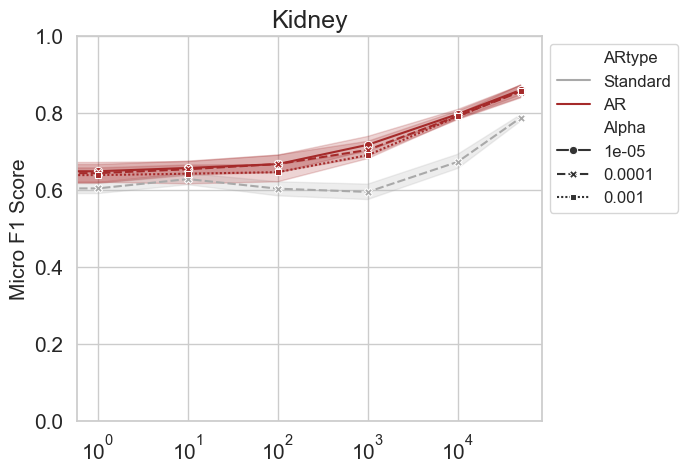

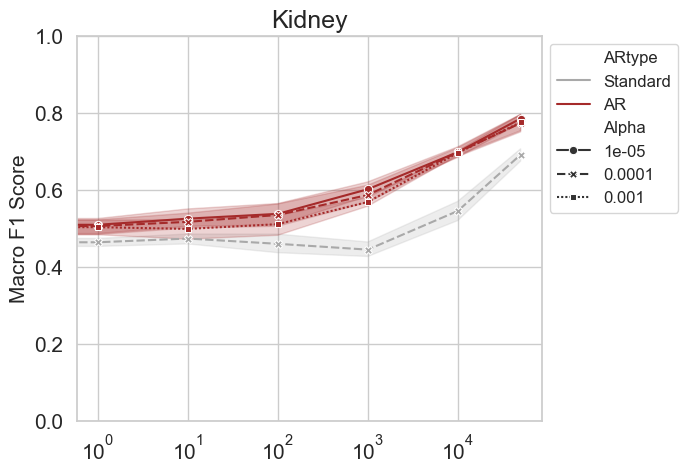

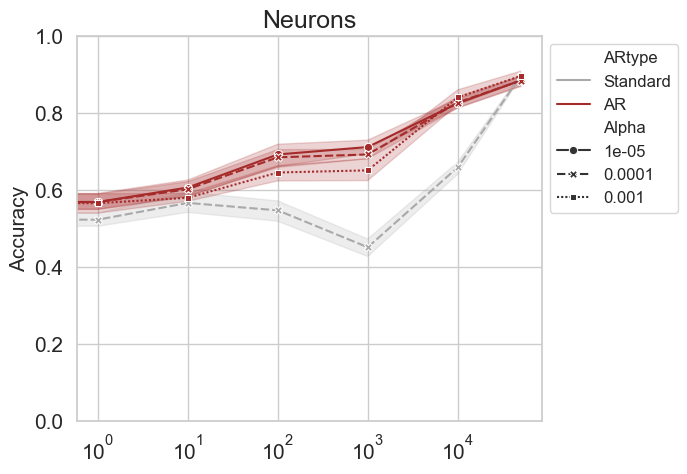

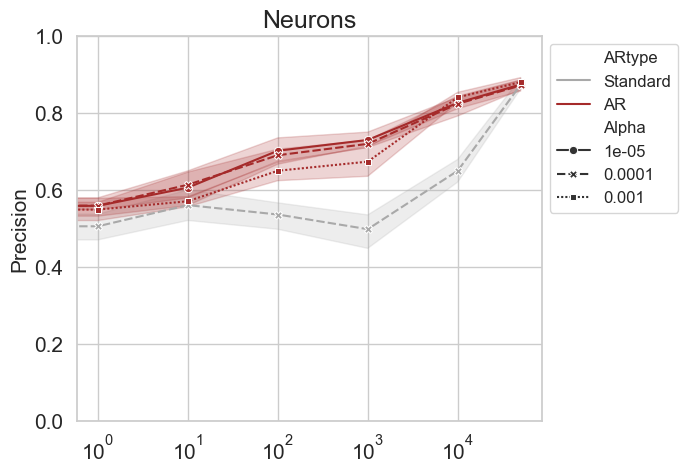

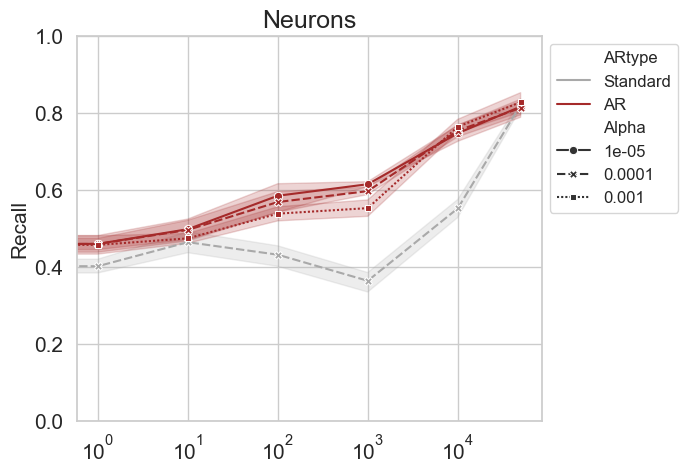

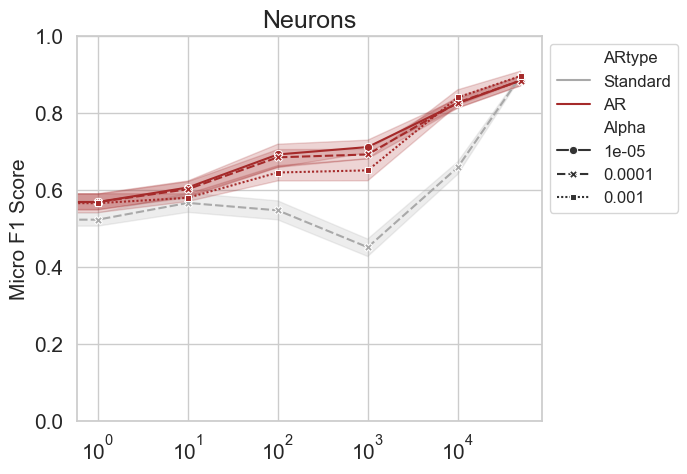

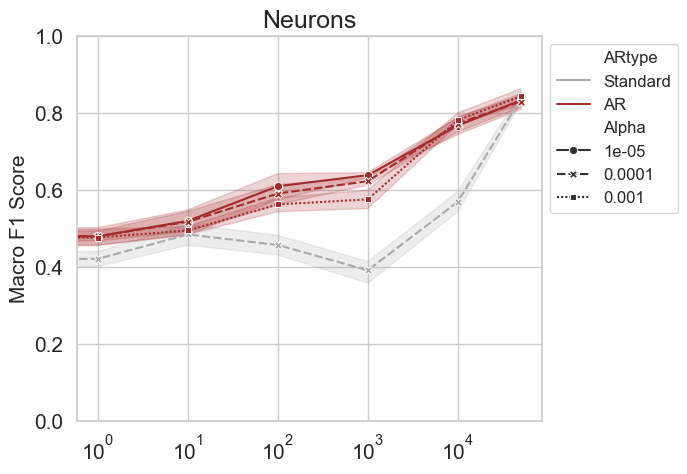

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
# plot a group barplot for each dataset with metric in x-axis and value in y-axis, hue=AR_Type
palette = {'Standard':"darkgray",
           'AR':"brown"}
for dataset in plot_df['dataset'].unique():
    
    # loop through each metric
    for i, metric in enumerate(metrics):
        # create a new plot
        fig, axs = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        # Use hue to differentiate ARtype and style to differentiate alpha values with different colors and line styles
        g = sns.lineplot(data=plot_df[(plot_df['dataset'] == dataset) & (plot_df['metric'] == metric)], 
                         x="Atlas_cell_count", y="value", hue="ARtype", style="Alpha",
                         palette=palette, hue_order=['Standard', 'AR'],
                         markers=True, dashes=True)
        # set x and y labels
        g.set_xlabel('')
        g.set_ylabel(metric, fontsize=15)
        # set the title of the plot
        g.set_title(dataset.capitalize(), fontsize=18)
        # set the font size of the x and y ticks
        g.tick_params(axis='both', which='major', labelsize=15)
        g.tick_params(axis='both', which='minor', labelsize=15)
        # g.legend(loc='upper left', fontsize=15)
        # locate legend outside the plot
        g.legend(loc='upper left', fontsize=12, bbox_to_anchor=(1, 1))
        g.set(ylim=(0, 1))
        g.set_xscale("log", base=10)
        # save the plot with high resolution
        plt.savefig(f'/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/figure/evals_for_new_alphas-4-7-26/{dataset}_{metric}.png', dpi=600,
                    bbox_inches='tight')
        plt.show()


Generate plot for reconstruction error

In [16]:
## Read reconstruction error for original evaluation of alpha=0.0001
import pickle
import os
import pandas as pd


df = pd.DataFrame(columns=['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'seed', 'Alpha'])
dir ='../result/test/sctab/zeinab-reconstruction-evals-20250409-manuscript-version/'
# loop over all files inside dir and read the pickle files
for file in os.listdir(dir):
    if file.endswith(".pkl") and 'Reconstruction_seed_' in file:
        # print(file)
        
        # extract the dataset name, ARtype, seed and Atlas_cell_count from the file name
        ARtype = file.split('_')[4]
        seed = file.split('_')[2]
        Atlas_cell_count = file.split('_')[11]
        alpha = 0.0001
        print('ARtype:', ARtype)
        print('seed:', seed)
        print('Atlas_cell_count:', Atlas_cell_count)
    
        # Open the pickle file in read-binary mode
        with open(dir+file, "rb") as f:
            data = pickle.load(f)
            print(list(data.keys()))
            dict_keys = list(data.keys())
            for key in dict_keys:
                test_df = data[key]
                print(test_df.columns)
                mean_r2 = test_df['r2'].mean()
                mean_corr = test_df['correlation'].mean()
                df.loc[len(df)] = [key, 'correlation', mean_corr, ARtype, Atlas_cell_count, seed, alpha]
                df.loc[len(df)] = [key, 'r2', mean_r2, ARtype, Atlas_cell_count, seed, alpha]


ARtype: T
seed: 46
Atlas_cell_count: 1000
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: F
seed: 45
Atlas_cell_count: 50000
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: T
seed: 43
Atlas_cell_count: 10
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: T
seed: 45
Atlas_cell_count: 1000
['scTab_Heart_reconstru

In [17]:
## Read reconstruction error for new evaluation of alpha=0.001 and 0.00001

dir ='/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/new_alpha_values/test/scVI-reconstruction-evals-4-7-26/'
# loop over all files inside dir and read the pickle files
for file in os.listdir(dir):
    if file.endswith(".pkl") and 'Reconstruction_seed_' in file:
        # print(file)
        
        # extract the dataset name, ARtype, seed and Atlas_cell_count from the file name
        ARtype = file.split('_')[4]
        seed = file.split('_')[2]
        Atlas_cell_count = file.split('_')[11]
        print(file.split('_')[-3])
        alpha = file.split('_')[-4]
        print('ARtype:', ARtype)
        print('seed:', seed)
        print('Atlas_cell_count:', Atlas_cell_count)
        print('alpha:', alpha)
    
        # Open the pickle file in read-binary mode
        with open(dir+file, "rb") as f:
            data = pickle.load(f)
            print(list(data.keys()))
            dict_keys = list(data.keys())
            for key in dict_keys:
                test_df = data[key]
                print(test_df.columns)
                mean_r2 = test_df['r2'].mean()
                mean_corr = test_df['correlation'].mean()
                df.loc[len(df)] = [key, 'correlation', mean_corr, ARtype, Atlas_cell_count, seed, alpha]
                df.loc[len(df)] = [key, 'r2', mean_r2, ARtype, Atlas_cell_count, seed, alpha]

Original Combination
ARtype: T
seed: 45
Atlas_cell_count: 1000
alpha: 0.001
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
Original Combination
ARtype: T
seed: 45
Atlas_cell_count: 0
alpha: 1e-05
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
Original Combination
ARtype: T
seed: 45
Atlas_cell_count: 1
alpha: 1e-05
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'super

In [18]:
# include only rows with seed in [42, 43, 44, 45, 46]
df = df[df['seed'].isin(['42', '43', '44', '45', '46'])]
print(df[df['ARtype'] == 'T'].shape[0])
print(df[df['ARtype'] == 'F'].shape[0])

print('df[df[seed] == 42].shape[0]:', df[df['seed'] == '42'].shape[0])
print('df[df[seed] == 43].shape[0]:', df[df['seed'] == '43'].shape[0])
print('df[df[seed] == 44].shape[0]:', df[df['seed'] == '44'].shape[0])
print('df[df[seed] == 45].shape[0]:', df[df['seed'] == '45'].shape[0])
print('df[df[seed] == 46].shape[0]:', df[df['seed'] == '46'].shape[0])

# print the number of rows for each Atlas_cell_count
print('Atlas_cell_count:', df['Atlas_cell_count'].unique())
# print the number of rows for each Atlas_cell_count=0,1,10,100,1000,10000,50000
print('Atlas_cell_count=0:', df[df['Atlas_cell_count'] == '0'].shape[0])
print('Atlas_cell_count=1:', df[df['Atlas_cell_count'] == '1'].shape[0])
print('Atlas_cell_count=10:', df[df['Atlas_cell_count'] == '10'].shape[0])
print('Atlas_cell_count=100:', df[df['Atlas_cell_count'] == '100'].shape[0])
print('Atlas_cell_count=1000:', df[df['Atlas_cell_count'] == '1000'].shape[0])
print('Atlas_cell_count=10000:', df[df['Atlas_cell_count'] == '10000'].shape[0])
print('Atlas_cell_count=50000:', df[df['Atlas_cell_count'] == '50000'].shape[0])


# assert df[df['ARtype'] == 'T'].shape[0] == df[df['ARtype'] == 'F'].shape[0]
# assert if the number of rows for each seed is the same
assert df[df['seed'] == '42'].shape[0] \
    == df[df['seed'] == '43'].shape[0] \
    == df[df['seed'] == '44'].shape[0] \
    == df[df['seed'] == '45'].shape[0] \
    == df[df['seed'] == '46'].shape[0] 
    

# print number of rows groouped by dataset, Atlas_cell_count, ARtype, , Alpha only for metric Correlation
print('number of rows groouped by dataset, Atlas_cell_count, ARtype, , Alpha only for metric Correlation:', df[df['metric'] == 'correlation'].groupby(['dataset', 'Atlas_cell_count', 'ARtype', 'Alpha']).size())
df.shape

630
210
df[df[seed] == 42].shape[0]: 168
df[df[seed] == 43].shape[0]: 168
df[df[seed] == 44].shape[0]: 168
df[df[seed] == 45].shape[0]: 168
df[df[seed] == 46].shape[0]: 168
Atlas_cell_count: ['1000' '50000' '10' '1' '0' '100' '10000']
Atlas_cell_count=0: 120
Atlas_cell_count=1: 120
Atlas_cell_count=10: 120
Atlas_cell_count=100: 120
Atlas_cell_count=1000: 120
Atlas_cell_count=10000: 120
Atlas_cell_count=50000: 120
number of rows groouped by dataset, Atlas_cell_count, ARtype, , Alpha only for metric Correlation: dataset                      Atlas_cell_count  ARtype  Alpha 
Neurons_reconstruction       0                 F       0.0001    5
                                               T       0.0001    5
                                                       0.001     5
                                                       1e-05     5
                             1                 F       0.0001    5
                                                                ..
scTab_Kidney_reconst

(840, 7)

In [19]:
# if 'heart' in df.dataset.lower, change it to 'Heart', if 'kidney' in df.dataset.lower, change it to 'Kidney'
df['dataset'] = df['dataset'].apply(lambda x: 'Heart' if 'heart' in x.lower() else x)
df['dataset'] = df['dataset'].apply(lambda x: 'Kidney' if 'kidney' in x.lower() else x)
df['dataset'] = df['dataset'].apply(lambda x: 'Neurons' if x=='Neurons_reconstruction' else x)

In [20]:
# replace ARtype with Standard
df['ARtype'] = df['ARtype'].apply(lambda x: 'Standard' if x == 'F' else 'AR')

In [21]:
# # write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and Naive using t-test
# from scipy import stats
# results = []

# for dataset in df['dataset'].unique():
#     for metric in df['metric'].unique():
#         for atlas_cell_count in df['Atlas_cell_count'].unique():
#             ar_values = df[(df['dataset'] == dataset) & 
#                                 (df['metric'] == metric) & 
#                                 (df['Atlas_cell_count'] == atlas_cell_count) & 
#                                 (df['ARtype'] == 'AR')]['value']
#             naive_values = df[(df['dataset'] == dataset) & 
#                                    (df['metric'] == metric) & 
#                                    (df['Atlas_cell_count'] == atlas_cell_count) & 
#                                    (df['ARtype'] == 'Standard')]['value']
#             if len(ar_values) > 1 and len(naive_values) > 1:
#                 t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
#                 results.append([dataset, metric, atlas_cell_count, p_value])
#             else:
#                 results.append([dataset, metric, atlas_cell_count, None])

In [22]:
# # convert results to a dataframe
# results_df = pd.DataFrame(results)
# results_df.columns = ['dataset', 'metric', 'Atlas_cell_count', 'p_value']
# print('shape of results_df:', results_df.shape)
# results_df

In [23]:
# # print the latex table of results_df, with dataset in caption, colored by their p-value (green for p<0.05, yellow for p>=0.05)
# for dataset in results_df['dataset'].unique():
#     subset = results_df[results_df['dataset'] == dataset]
#     pivot_table = subset.pivot(index='metric', columns='Atlas_cell_count', values='p_value')
#     def color_pval(val):
#         if pd.isna(val):
#             return ''
#         elif val < 0.05:
#             return 'background-color: green; color: white;'
#         else:
#             return 'background-color: yellow; color: black;'
#     styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
#     latex_table = styled_table.to_latex(caption=f'P-values for {dataset}', label=f'tab:pvalues_{dataset}')
#     print(latex_table)

In [24]:

# # plot heatmap of p-values for each dataset, where x axis is Atlas_cell_count, y axis is metric, and color is green if p-value < 0.05 else red
# import seaborn as sns
# import matplotlib.pyplot as plt
# results_df = results_df[results_df['metric'].isin(['correlation'])]
# for dataset in results_df['dataset'].unique():
#     pivot_df = results_df[results_df['dataset'] == dataset].pivot(index='metric', columns='Atlas_cell_count', values='p_value')
#     plt.figure(figsize=(10, 2))
#     sns.heatmap(pivot_df, annot=True, fmt=".1e", cmap=sns.color_palette(["green", "red"]), center=0.05, cbar_kws={'label': 'p-value'})
#     plt.title(f'P-values Heatmap for {dataset}')
#     plt.xlabel('Atlas Cell Count')
#     plt.ylabel('Metric')
#     plt.axhline(y=-0.5, color='black', linewidth=2)  # Horizontal line at the top
#     plt.axvline(x=-0.5, color='black', linewidth=2)  # Vertical line at the left
#     plt.tight_layout()
#     plt.show()


/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_10101/2976102734.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


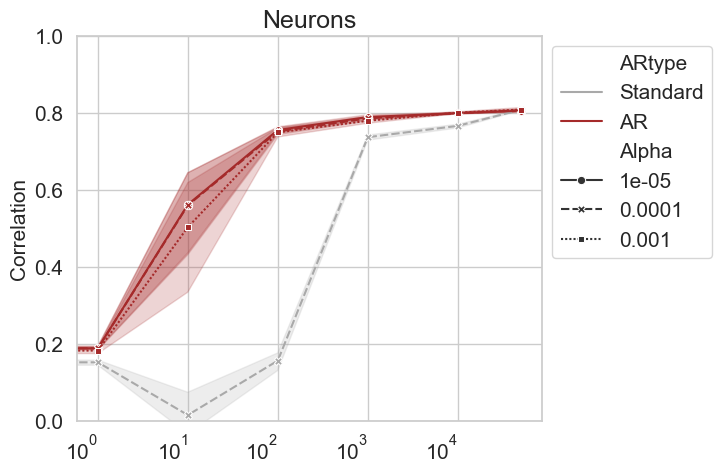

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_10101/2976102734.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


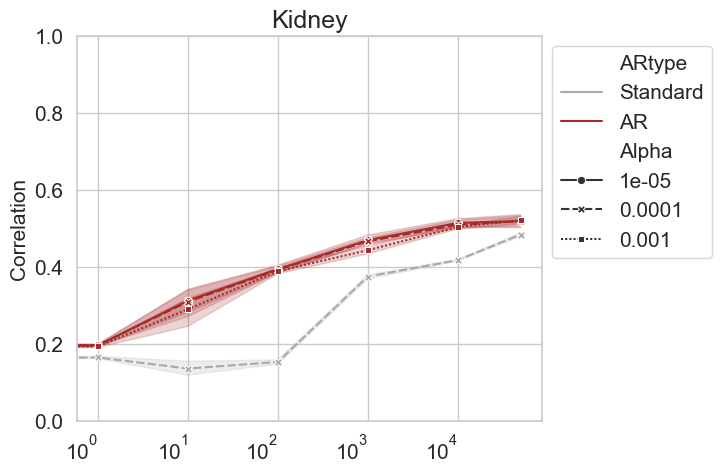

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_10101/2976102734.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


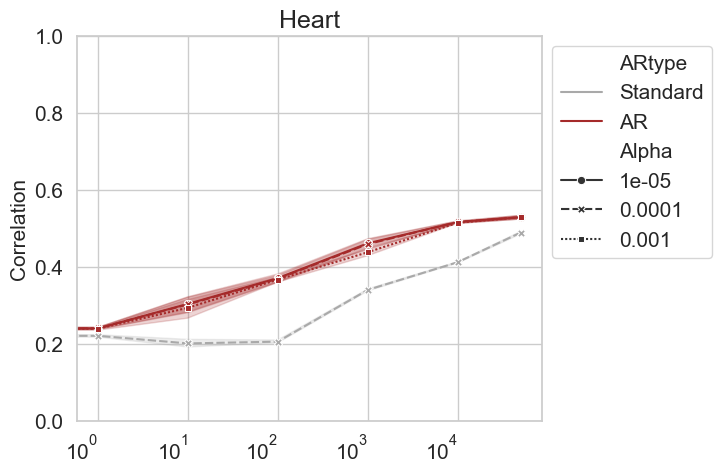

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# plot group barplot with Atlas_cell_count in x-axis, value in y-axis, hue=ARtype
# convert Atlas_cell_count to log scale

# convert the Atlas_cell_count label into int format
df['Atlas_cell_count'] = df['Atlas_cell_count'].astype(int)
# sort based on Atlas_cell_count
df = df.sort_values(by='Atlas_cell_count')

# plot a group barplot for each dataset with metric in x-axis and value in y-axis, hue=AR_Type
palette = {'Standard':"darkgray",
           'AR':"brown"}

for dataset in df['dataset'].unique():
    # loop through each metric
    for i, metric in enumerate(['correlation']):
        fig, axs = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        # Use hue to differentiate ARtype and style to differentiate alpha values with different colors and line styles
        g = sns.lineplot(data=df[(df['dataset'] == dataset) & (df['metric'] == metric)], 
                         x="Atlas_cell_count", y="value", hue="ARtype", style="Alpha",
                         palette=palette, hue_order=['Standard', 'AR'],
                         markers=True, dashes=True)
        # set x and y labels
        g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')
        g.set_xlabel('')
        g.set_ylabel(metric.capitalize(), fontsize=15)
        g.set_title(dataset.capitalize(), fontsize=18)
        g.tick_params(axis='both', which='major', labelsize=15)
        g.tick_params(axis='both', which='minor', labelsize=15)
        g.set_xscale("log", base=10)
        g.legend(loc='upper left', fontsize=15, bbox_to_anchor=(1, 1))
        g.set(ylim=(0,1))
        
        # save the plot with high resolution
        plt.savefig(f'/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/figure/evals_for_new_alphas-4-7-26/{dataset}_{metric}.png', dpi=600,
                    bbox_inches='tight')
        plt.show()
        
        